# Objective

This notebook treats the per-image localization change as a continuous regression target:

IoU change = IoU_960 - IoU_640

The analysis will:

1. Test whether image metadata can predict which images benefit from higher resolution.
2. Compare a mean baseline, Ridge regression, and Random Forest regression.
3. Use grouped cross-validation so frames from the same vehicle track never appear in both training and validation folds.
4. Estimate feature importance using only held-out folds.
5. Check whether the extreme improvement observed for `track0067` drives the results.

In [70]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [71]:
CURRENT_DIRECTORY = Path.cwd()

PROJECT_ROOT = CURRENT_DIRECTORY.parent

ANALYSIS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "prediction_analysis.csv"
)

REPORT_DIR = PROJECT_ROOT / "reports" / "regression"
FIGURE_DIR = REPORT_DIR / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


In [72]:
# Results from last notebook
if not ANALYSIS_PATH.exists():
    raise FileNotFoundError(
        "prediction_analysis.csv was not found. Run 03_analysis.ipynb "
        "and save the merged prediction table first."
    )

analysis = pd.read_csv(ANALYSIS_PATH)

# Support either the original blur-score names or the clearer sharpness names.
if "plate_sharpness" not in analysis.columns and "plate_blur_score" in analysis.columns:
    analysis["plate_sharpness"] = analysis["plate_blur_score"]

if "image_sharpness" not in analysis.columns and "image_blur_score" in analysis.columns:
    analysis["image_sharpness"] = analysis["image_blur_score"]

# Recreate the target
if "iou_change_960_minus_640" not in analysis.columns:
    required_prediction_columns = {"top_iou_640", "top_iou_960"}
    missing_prediction_columns = required_prediction_columns - set(analysis.columns)

    if missing_prediction_columns:
        raise KeyError(
            "Cannot create the regression target. Missing columns: "
            f"{sorted(missing_prediction_columns)}"
        )

    analysis["iou_change_960_minus_640"] = (
        analysis["top_iou_960"] - analysis["top_iou_640"]
    )

required_columns = {
    "image_name",
    "track_id",
    "iou_change_960_minus_640",
}

missing_required_columns = required_columns - set(analysis.columns)

if missing_required_columns:
    raise KeyError(
        f"Missing required columns: {sorted(missing_required_columns)}"
    )

analysis = (
    analysis
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["track_id", "iou_change_960_minus_640"])
    .reset_index(drop=True)
)

print("Images:", len(analysis))
print("Tracks:", analysis["track_id"].nunique())
print("Mean IoU change:", analysis["iou_change_960_minus_640"].mean())
print("Median IoU change:", analysis["iou_change_960_minus_640"].median())
print(
    "Images improved:",
    (analysis["iou_change_960_minus_640"] > 0).sum(),
    "out of",
    len(analysis),
)


Images: 900
Tracks: 30
Mean IoU change: 0.03798982471830357
Median IoU change: 0.01610647545238175
Images improved: 568 out of 900


In [73]:
# Define numerical and categorical variables
numeric_feature_candidates = [
    "plate_area_ratio",
    "plate_aspect_ratio",
    "plate_width",
    "plate_height",
    "plate_brightness",
    "plate_contrast",
    "plate_sharpness",
    "image_brightness",
    "image_contrast",
    "image_sharpness",
]

categorical_feature_candidates = [
    "camera",
    "vehicle_type",
]

numeric_features = [
    column
    for column in numeric_feature_candidates
    if column in analysis.columns
]

categorical_features = [
    column
    for column in categorical_feature_candidates
    if column in analysis.columns
]

model_features = numeric_features + categorical_features

if not model_features:
    raise ValueError("No candidate regression features were found.")

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Total features before encoding:", len(model_features))

missing_values = analysis[model_features].isna().sum()
missing_values[missing_values > 0]


Numeric features: ['plate_area_ratio', 'plate_aspect_ratio', 'plate_width', 'plate_height', 'plate_brightness', 'plate_contrast', 'plate_sharpness', 'image_brightness', 'image_contrast', 'image_sharpness']
Categorical features: ['camera', 'vehicle_type']
Total features before encoding: 12


Series([], dtype: int64)

In [74]:
target_column = "iou_change_960_minus_640"

for column in numeric_features:
    analysis[column] = analysis[column].fillna(
        analysis[column].median()
    )

for column in categorical_features:
    analysis[column] = analysis[column].fillna("Unknown")

X = analysis[model_features].copy()
y = analysis[target_column].copy()
groups = analysis["track_id"].copy()

print("X shape:", X.shape)
print("Unique groups:", groups.nunique())


X shape: (900, 12)
Unique groups: 30


The models are:

- **Mean baseline:** predicts the training-fold mean IoU change for every image.
- **Ridge regression:** estimates a regularized linear relationship.
- **Random Forest regression:** captures nonlinear relationships and interactions.

Evaluation metrics:

- **MAE:** average absolute prediction error in IoU units; lower is better.
- **RMSE:** penalizes larger errors more strongly; lower is better.
- **R²:** fraction of target variation explained on held-out tracks; higher is better. A negative R² means the model performs worse than predicting the mean.

In [75]:
try:
    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
    )
except TypeError:
    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False,
    )

transformers = []

if numeric_features:
    transformers.append(
        (
            "numeric",
            StandardScaler(),
            numeric_features,
        )
    )

if categorical_features:
    transformers.append(
        (
            "categorical",
            categorical_encoder,
            categorical_features,
        )
    )

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
)

models = {
    "Mean baseline": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", DummyRegressor(strategy="mean")),
        ]
    ),
    "Ridge regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", Ridge(alpha=1.0)),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=500,
                    min_samples_leaf=5,
                    max_features="sqrt",
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}


In [76]:
def evaluate_regressors(X_data, y_data, group_data, model_dictionary):
    # Evaluate models with out-of-fold predictions grouped by track.
    number_of_splits = min(5, group_data.nunique())

    if number_of_splits < 2:
        raise ValueError("At least two unique tracks are required.")

    cross_validation = GroupKFold(n_splits=number_of_splits)

    metric_records = []
    prediction_frame = pd.DataFrame(
        {
            "actual_iou_change": y_data.to_numpy(),
            "track_id": group_data.to_numpy(),
        },
        index=y_data.index,
    )

    for model_name, pipeline in model_dictionary.items():
        out_of_fold_predictions = cross_val_predict(
            pipeline,
            X_data,
            y_data,
            groups=group_data,
            cv=cross_validation,
            n_jobs=1,
            method="predict",
        )

        metric_records.append(
            {
                "model": model_name,
                "mae": mean_absolute_error(
                    y_data,
                    out_of_fold_predictions,
                ),
                "rmse": mean_squared_error(
                    y_data,
                    out_of_fold_predictions,
                    squared=False,
                ),
                "r2": r2_score(
                    y_data,
                    out_of_fold_predictions,
                ),
            }
        )

        safe_model_name = (
            model_name
            .lower()
            .replace(" ", "_")
        )

        prediction_frame[
            f"predicted_{safe_model_name}"
        ] = out_of_fold_predictions

    metrics = (
        pd.DataFrame(metric_records)
        .sort_values(["mae", "rmse"])
        .reset_index(drop=True)
    )

    return metrics, prediction_frame


model_metrics, out_of_fold_predictions = evaluate_regressors(
    X,
    y,
    groups,
    models,
)

model_metrics

# Neither models performed better than the baseline mean. Random Forest is the best performance but has high MAE and RMSE. 
# R2 was also all negative which means none explained the variation in IoU change better than the baseline prediction

,model,mae,rmse,r2
0,Mean baseline,0.071284,0.159696,-0.018555
1,Random Forest,0.082560,0.171850,-0.179486
2,Ridge regression,0.102777,0.182502,-0.330250


In [77]:
model_metrics.to_csv(
    REPORT_DIR / "regression_metrics.csv",
    index=False,
)

prediction_export = pd.concat(
    [
        analysis[["image_name"]],
        out_of_fold_predictions.reset_index(drop=True),
    ],
    axis=1,
)

prediction_export.to_csv(
    REPORT_DIR / "out_of_fold_predictions.csv",
    index=False,
)

print("Saved metrics and out-of-fold predictions to:", REPORT_DIR)


Saved metrics and out-of-fold predictions to: c:\Users\mingj\Desktop\Plate-Recognition\reports\regression


In [78]:
# Find best model which is lower MAE and RMSE
learned_model_metrics = model_metrics.loc[
    model_metrics["model"] != "Mean baseline"
].copy()

best_model_name = (
    learned_model_metrics
    .sort_values(["mae", "rmse"])
    .iloc[0]["model"]
)

best_prediction_column = (
    "predicted_"
    + best_model_name.lower().replace(" ", "_")
)

print("Best learned model by MAE:", best_model_name)

best_row = model_metrics.loc[
    model_metrics["model"] == best_model_name
].iloc[0]

baseline_row = model_metrics.loc[
    model_metrics["model"] == "Mean baseline"
].iloc[0]

print("Best-model MAE:", best_row["mae"])
print("Baseline MAE:", baseline_row["mae"])
print("Best-model R²:", best_row["r2"])

if best_row["mae"] < baseline_row["mae"] and best_row["r2"] > 0:
    print(
        "Interpretation: the metadata provides useful out-of-track "
        "predictive information."
    )
else:
    print(
        "Interpretation: the metadata does not clearly outperform a "
        "mean prediction on unseen tracks."
    )

# 

Best learned model by MAE: Random Forest
Best-model MAE: 0.08255957930180083
Baseline MAE: 0.07128410817976279
Best-model R²: -0.1794855001488762
Interpretation: the metadata does not clearly outperform a mean prediction on unseen tracks.


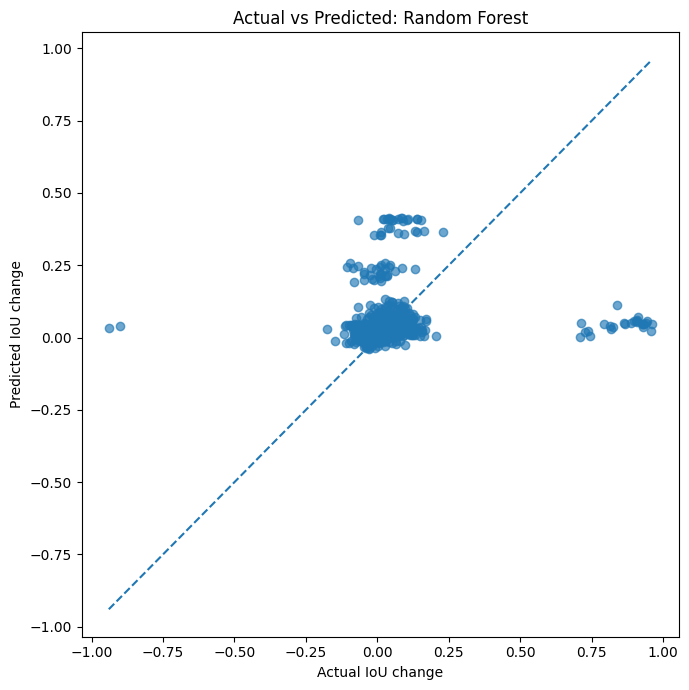

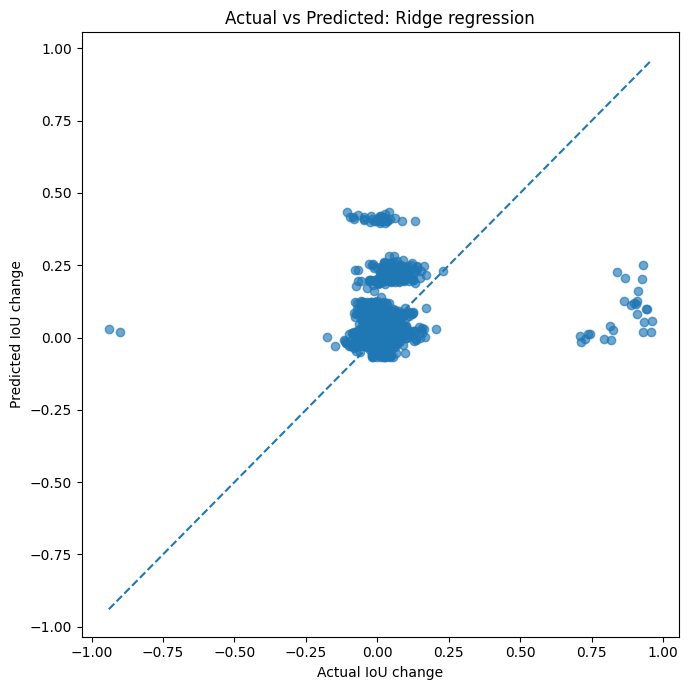

In [79]:
# Visualize
for model_name in learned_model_metrics["model"]:
    prediction_column = (
        "predicted_"
        + model_name.lower().replace(" ", "_")
    )

    actual_values = out_of_fold_predictions["actual_iou_change"]
    predicted_values = out_of_fold_predictions[prediction_column]

    minimum = min(actual_values.min(), predicted_values.min())
    maximum = max(actual_values.max(), predicted_values.max())

    plt.figure(figsize=(7, 7))
    plt.scatter(actual_values, predicted_values, alpha=0.65)
    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
    )
    plt.xlabel("Actual IoU change")
    plt.ylabel("Predicted IoU change")
    plt.title(f"Actual vs Predicted: {model_name}")
    plt.tight_layout()
    plt.show()

# Both random forest and ridge regression both have predictions concentrated at 0 which means the model regresses toward the mean rather than accurately predicting extreme localization changes


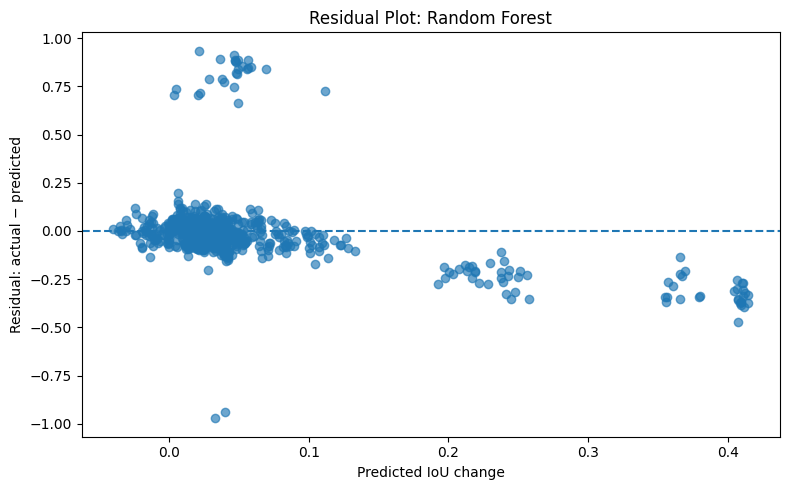

In [80]:
best_actual = out_of_fold_predictions["actual_iou_change"]
best_predicted = out_of_fold_predictions[best_prediction_column]
best_residuals = best_actual - best_predicted

plt.figure(figsize=(8, 5))
plt.scatter(best_predicted, best_residuals, alpha=0.65)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted IoU change")
plt.ylabel("Residual: actual − predicted")
plt.title(f"Residual Plot: {best_model_name}")
plt.tight_layout()
plt.show()

# Images with large predicted improvements have negative residuals (overestimation) while some moderate predictions exhibit large positive residuals (underestimation). This suggests that important variables are missing and that prediction errors are driven by outside factors.

In [81]:
# Checks if the models depend heavily on one track since Track0067 was an extreme case
largest_improvement_track = (
    analysis
    .groupby("track_id")[target_column]
    .mean()
    .idxmax()
)

largest_track_rows = analysis.loc[
    analysis["track_id"] == largest_improvement_track
]

print("Largest-improvement track:", largest_improvement_track)
print(
    "Mean IoU change:",
    largest_track_rows[target_column].mean(),
)
print("Frames:", len(largest_track_rows))

if "plate_area_ratio" in largest_track_rows.columns:
    print(
        "Mean plate-area ratio:",
        largest_track_rows["plate_area_ratio"].mean(),
    )

# Track0067 is still the most influential track to be improved

Largest-improvement track: track0067
Mean IoU change: 0.4348248270706343
Frames: 30
Mean plate-area ratio: 0.0008111175411522034


In [82]:
# Remove that track
sensitivity_mask = analysis["track_id"] != largest_improvement_track

X_sensitivity = analysis.loc[sensitivity_mask, model_features].copy()
y_sensitivity = analysis.loc[sensitivity_mask, target_column].copy()
groups_sensitivity = analysis.loc[sensitivity_mask, "track_id"].copy()

sensitivity_metrics, _ = evaluate_regressors(
    X_sensitivity,
    y_sensitivity,
    groups_sensitivity,
    models,
)

comparison_metrics = model_metrics.merge(
    sensitivity_metrics,
    on="model",
    suffixes=("_all_tracks", "_without_largest_track"),
)

comparison_metrics

# It reduced prediction errors for all models but the ranking of the models remained unchanged and all R² values stayed negative

,model,mae_all_tracks,rmse_all_tracks,r2_all_tracks,mae_without_largest_track,rmse_without_largest_track,r2_without_largest_track
0,Mean baseline,0.071284,0.159696,-0.018555,0.055293,0.117317,-0.012583
1,Random Forest,0.082560,0.171850,-0.179486,0.060672,0.121502,-0.086105
2,Ridge regression,0.102777,0.182502,-0.330250,0.070084,0.124747,-0.144901


In [83]:
# Permutation importance measures performance of features by observing the change in the model's performance when that feature's information is destroyed. 
# Importance is calculated separately inside each grouped validation fold and then averaged.
best_pipeline = models[best_model_name]
importance_cross_validation = GroupKFold(n_splits=5)
importance_records = []

for fold_number, (train_indices, validation_indices) in enumerate(
    importance_cross_validation.split(X, y, groups),
    start=1,
):
    fold_model = clone(best_pipeline)

    fold_model.fit(
        X.iloc[train_indices],
        y.iloc[train_indices],
    )

    fold_importance = permutation_importance(
        fold_model,
        X.iloc[validation_indices],
        y.iloc[validation_indices],
        scoring="neg_mean_absolute_error",
        n_repeats=30,
        random_state=42 + fold_number,
        n_jobs=1,
    )

    for feature_name, importance_mean, importance_std in zip(
        model_features,
        fold_importance.importances_mean,
        fold_importance.importances_std,
    ):
        importance_records.append(
            {
                "fold": fold_number,
                "feature": feature_name,
                "importance": importance_mean,
                "within_fold_std": importance_std,
            }
        )

fold_importance_frame = pd.DataFrame(importance_records)

feature_importance = (
    fold_importance_frame
    .groupby("feature", as_index=False)
    .agg(
        mean_importance=("importance", "mean"),
        fold_std=("importance", "std"),
    )
    .sort_values("mean_importance", ascending=False)
)

feature_importance


,feature,mean_importance,fold_std
11,vehicle_type,0.001928,0.005938
3,image_sharpness,0.001292,0.001990
2,image_contrast,0.000452,0.001167
9,plate_sharpness,0.000444,0.000831
5,plate_aspect_ratio,0.000195,0.002930
8,plate_height,0.000044,0.000760
0,camera,-0.000225,0.002481
6,plate_brightness,-0.000413,0.001853
4,plate_area_ratio,-0.000476,0.000990
7,plate_contrast,-0.000824,0.001160


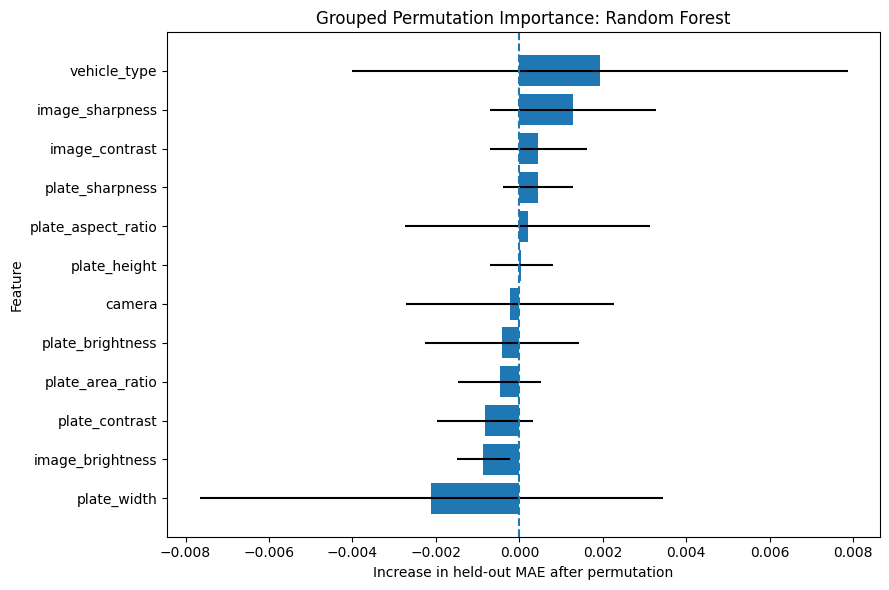

In [84]:
# Visualize the importance
feature_importance.to_csv(
    REPORT_DIR / "permutation_feature_importance.csv",
    index=False,
)

plot_importance = (
    feature_importance
    .sort_values("mean_importance")
)

plt.figure(figsize=(9, 6))
plt.barh(
    plot_importance["feature"],
    plot_importance["mean_importance"],
    xerr=plot_importance["fold_std"].fillna(0),
)
plt.axvline(0, linestyle="--")
plt.xlabel("Increase in held-out MAE after permutation")
plt.ylabel("Feature")
plt.title(f"Grouped Permutation Importance: {best_model_name}")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "permutation_feature_importance.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


# Conclusion

Increasing the resolution improved localization for many tracks but the magnitude of that improvement could not be reliably explained using plate size, brightness, contrast, sharpness, camera, or vehicle type alone. Important factors may be absent from the current metadata, such as viewing angle, perspective distortion, motion, occlusion, background complexity, or differences created during model training.